In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
transactions = pd.read_csv("../data/processed/clean_transaction.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [3]:
#Task 1 - VaR & CVaR
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

var_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns,5)

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_results.append([
            fund,
            var95,
            cvar95
        ])

var_cvar = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


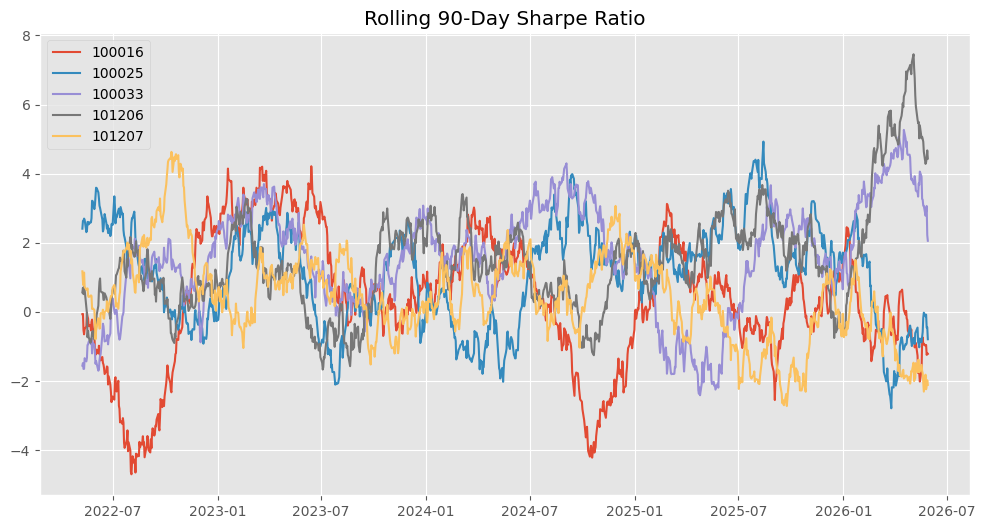

In [4]:
#Task 2 - Rolling Sharpe Ratio
top5 = nav["amfi_code"].unique()[:5]
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [5]:
#Task 3 - Investor Cohort Analysis
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)
cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg({
        "amount_inr":"mean"
    })
)

cohort_analysis.to_csv(
    "../data/processed/cohort_analysis.csv"
)

cohort_analysis

,amount_inr
cohort_year,
2024,107422.541832
2025,109158.577061


In [8]:
#Task 4 - SIP Continuity Analysis
sip = transactions[
    transactions["transaction_type"]
    == "Sip"
].copy()
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)
continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap=("gap_days","mean"),
        sip_count=("gap_days","count")
    )
    .reset_index()
)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["risk_flag"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Active"
)

continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

continuity.head()

,investor_id,avg_gap,sip_count,risk_flag
10,INV000011,40.166667,6,At Risk
11,INV000012,57.000000,7,At Risk
12,INV000013,55.333333,6,At Risk
13,INV000014,75.333333,6,At Risk
22,INV000023,58.571429,7,At Risk


In [9]:
#Task 6 - Sector concentration analysis
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if "holding" in file.lower() or "portfolio" in file.lower():
            print(file)

09_portfolio_holdings.csv


In [11]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data\processed\alpha_beta.csv
../data\processed\cagr_report.csv
../data\processed\clean_nav.csv
../data\processed\clean_performance.csv
../data\processed\clean_transaction.csv
../data\processed\cohort_analysis.csv
../data\processed\fund_scorecard.csv
../data\processed\max_drawdown.csv
../data\processed\returns_computed.csv
../data\processed\sharpe_values.csv
../data\processed\sip_continuity.csv
../data\processed\sortino_values.csv
../data\processed\tracking_error.csv
../data\processed\var_cvar_report.csv
../data\raw\01_fund_master.csv
../data\raw\02_nav_history.csv
../data\raw\03_aum_by_fund_house.csv
../data\raw\04_monthly_sip_inflows.csv
../data\raw\05_category_inflows.csv
../data\raw\06_industry_folio_count.csv
../data\raw\07_scheme_performance.csv
../data\raw\08_investor_transactions.csv
../data\raw\09_portfolio_holdings.csv
../data\raw\10_benchmark_indices.csv
../data\raw\Axis_Bluechip_NAV.csv
../data\raw\HDFC_Top100_NAV.csv
../data\raw\ICICI_Bluechip_NAV.csv
../data\raw\Kotak_

In [12]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [13]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [14]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [15]:
import numpy as np

sector_hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(
        lambda x: np.sum((x/100)**2)
    )
    .reset_index()
)

sector_hhi.columns = [
    "amfi_code",
    "HHI"
]

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [16]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

sector_hhi = sector_hhi.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [17]:
sector_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved successfully")

sector_hhi.csv saved successfully


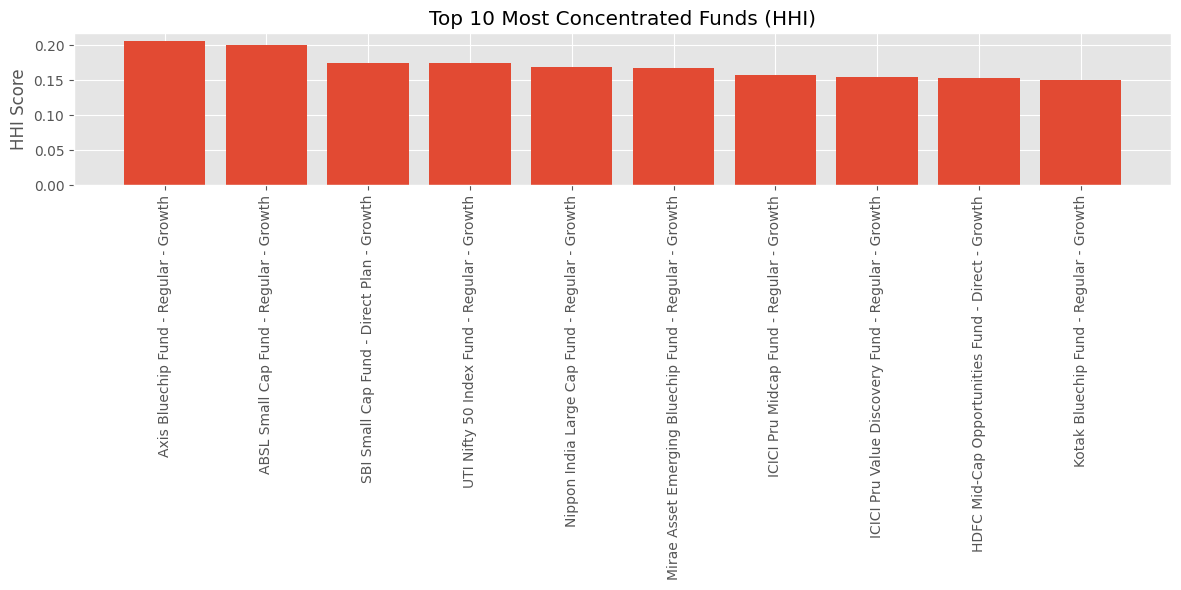

In [18]:
import matplotlib.pyplot as plt

top_hhi = (
    sector_hhi
    .sort_values(
        "HHI",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_hhi["scheme_name"],
    top_hhi["HHI"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Most Concentrated Funds (HHI)"
)

plt.ylabel("HHI Score")

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
#Task 7 - Advanced Analytics Summary

## Key Insights

- The VaR and CVaR analysis helped identify funds that are more vulnerable during market downturns and carry higher downside risk.
- The Rolling 90-Day Sharpe Ratio showed that fund performance is not constant over time and changes with market conditions, highlighting periods of strong and weak risk-adjusted returns.
- Investor cohort analysis revealed differences in investment behaviour across different groups of investors, with newer cohorts contributing significantly to overall investments.
- SIP continuity analysis helped identify investors who may be at risk of discontinuing their SIPs based on larger gaps between transactions.
- The fund recommendation model successfully matched investor risk profiles with suitable funds using Sharpe Ratio and risk grades.
- Sector concentration analysis highlighted funds that are heavily concentrated in a few sectors, making them more exposed to sector-specific risks.
- Overall, combining return metrics with risk metrics such as Sharpe Ratio, Sortino Ratio, VaR, CVaR, and Maximum Drawdown provided a more complete understanding of fund performance.

## Conclusion
This analysis demonstrates how data analytics can be used to evaluate mutual fund performance, measure investment risk, understand investor behaviour, and support data-driven investment decisions. The combination of performance analytics and risk assessment provides valuable insights for both investors and fund managers.

SyntaxError: invalid syntax (234196106.py, line 5)